In [64]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

In [41]:
# Start with a bigram language model, a very simple language model
# Looks only at two characters in a row: given previous character, what character is likely to come next?

In [49]:
# Look at pairs of consecutive characters in the words and count the frequency of each pair

b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] # start token + word + end token
    for ch1, ch2 in zip(chs, chs[1:]): # get pairs of consecutive characters
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 # if bigram is not in the dictionary, value = 1
        
b_sorted = sorted(b.items(), key = lambda kv: -kv[1])

In [50]:
# Correlation Matrix for bigrams

N = torch.zeros((28, 28), dtype = torch.int32)
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)} # lookup table to map characters to integers
stoi['<S>'] = 26
stoi['<E>'] = 27


for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1


(-0.5, 27.5, 27.5, -0.5)

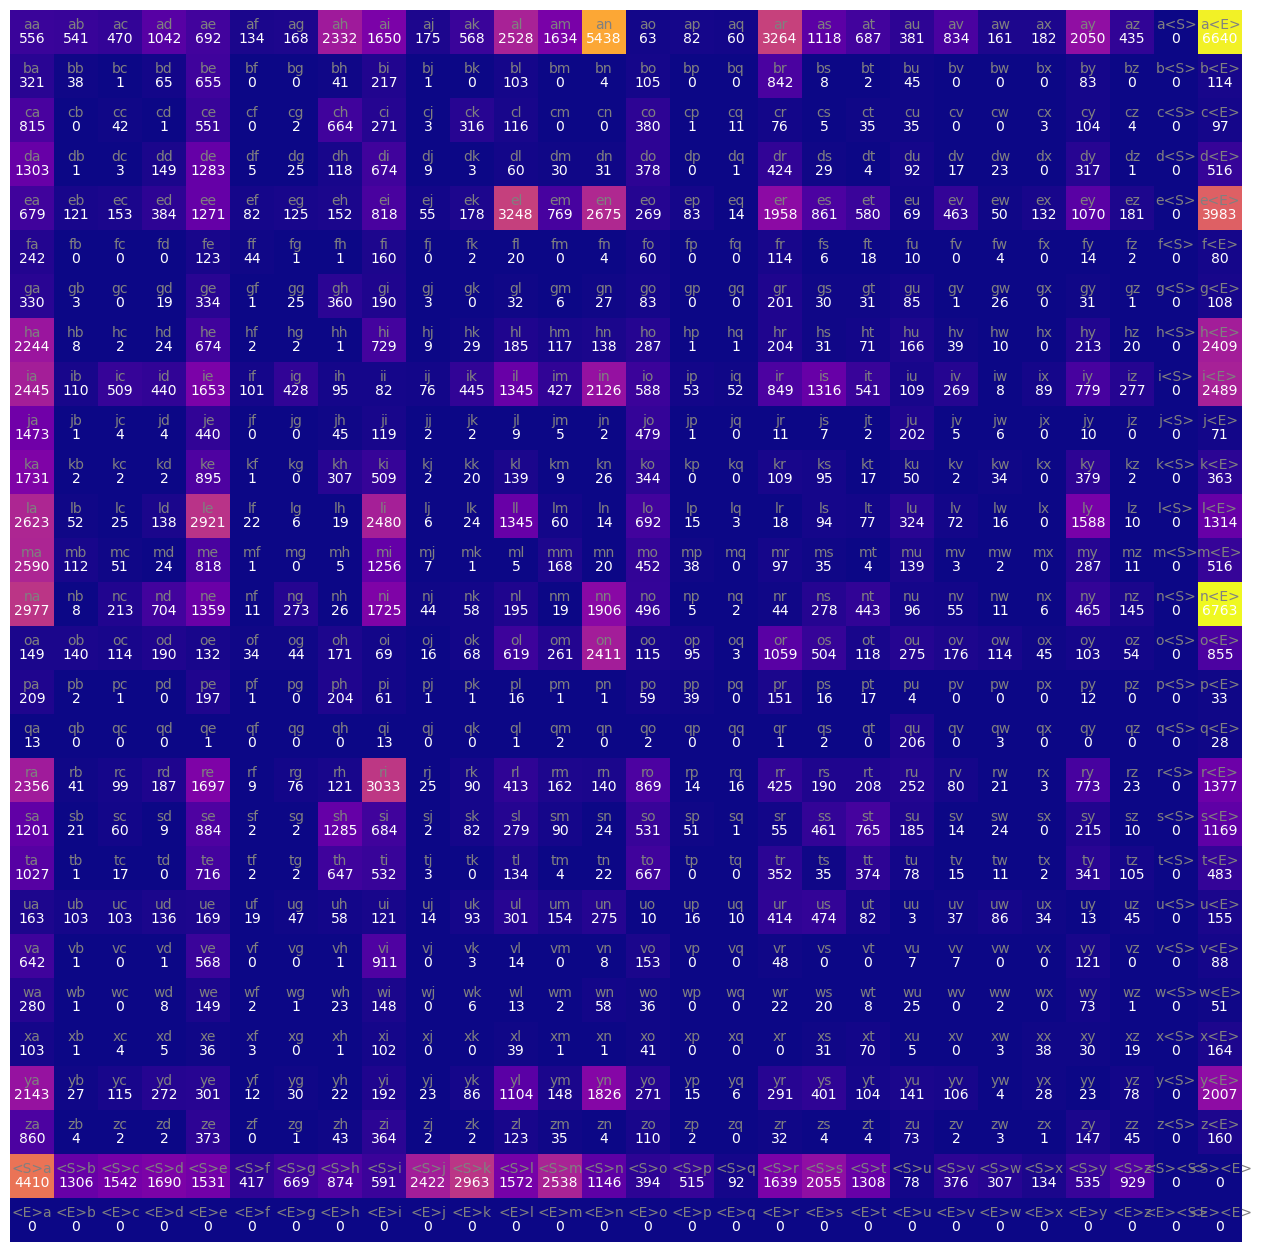

In [76]:
itos = {i:s for s, i in stoi.items()} # inverse of stoi

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='plasma')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='white')
plt.axis('off')